# Tutorial: 5-Transistor OTA Layout Generation using gLayout

**By gLayout Team**

**Content creators:** Adrian Sami Pratama, Dharma Anargya Jowandy

___
## 1. Introduction

### Tutorial Objectives

This notebook is a tutorial on:

- **Importing** and **Placement** of FETs and other macros/Pcells with relative coordinates, placing and connecting `via_stack` on the ports of the FETs, and encircling them with taprings.
- **Routing** between the placed vias using `straight_route`, `c_route`, and `L_route`, and understanding when to use each strategy based on port orientations.
- **Placing and connecting PINs** for future LVS runs.

### What is a 5T OTA?

A 5-Transistor Operational Transconductance Amplifier (5T OTA) is one of the most fundamental analog circuit building blocks. It converts a differential input voltage into an output current. The circuit consists of:

- **M1, M2** — Differential input pair (NMOS)
- **M3, M4** — Current mirror load (PMOS)
- **M5** — Tail current source (NMOS)

### Schematic Reference

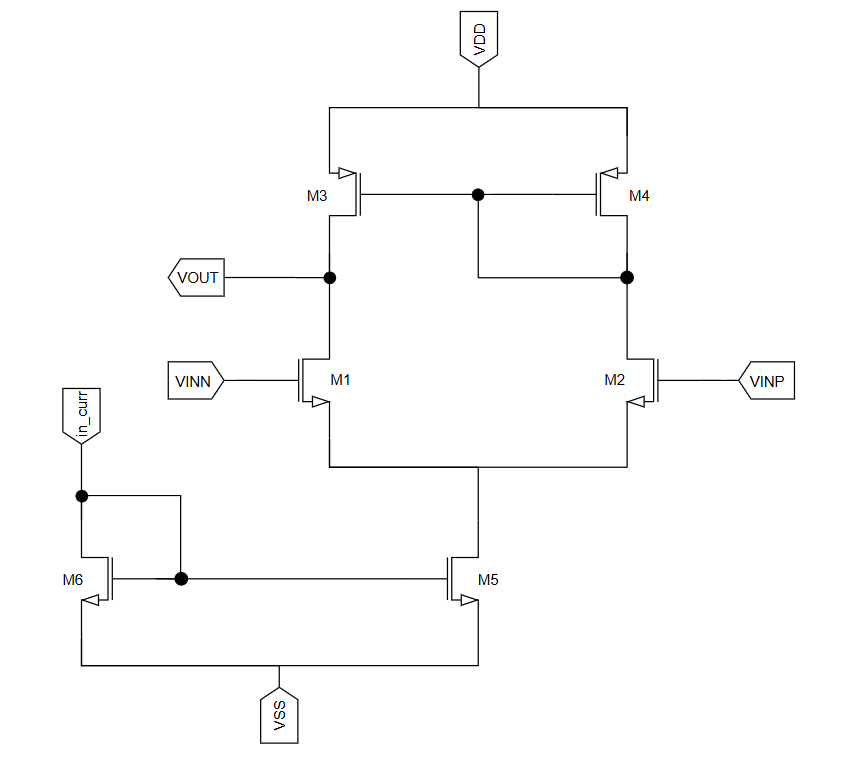


## 2. Environment Setup

### Setting Up the Live GDSII Viewer

We first source the shell environment to ensure all PDK-related environment variables are properly loaded into the Python session.

In [ ]:
import os
import subprocess

# Source .bashrc and load environment variables into the current Python session
cmd = 'bash -c "source ~/.bashrc && printenv"'
result = subprocess.run(cmd, shell=True, text=True, capture_output=True)
env_vars = {}
for line in result.stdout.splitlines():
    if '=' in line:
        key, value = line.split('=', 1)
        env_vars[key] = value

os.environ.update(env_vars)

We define two helper functions for displaying GDS output inline in the notebook. display_gds reads a GDS file and renders it as an SVG, while display_component wraps it to accept a gdsfactory Component object directly.

In [ ]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

hide = widgets.Output()

def display_gds(gds_file, path, scale=3):
    top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
    top_level_cell.write_svg(os.path.join(path, 'out.svg'))

    fig = sg.fromfile(os.path.join(path, 'out.svg'))
    fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
    fig.save(os.path.join(path, 'out.svg'))

    IPython.display.display(IPython.display.SVG(os.path.join(path, 'out.svg')))
    os.remove(os.path.join(path, 'out.gds'))

def display_component(component, path, scale=3):
    with hide:
        component.write_gds(os.path.join(path, 'out.gds'))
    display_gds(os.path.join(path, 'out.gds'), path, scale)

### Importing gLayout Libraries

In [ ]:
from glayout import MappedPDK, sky130, gf180
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle

from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring

from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter, print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route

## 3. Design Parameters & Configuration

### Transistor Kwargs

nmos_kwargs and pmos_kwargs are Python dictionaries that store a shared set of physical layout parameters for the transistors. Instead of repeating the same parameters in every nmos() or pmos() call, we define them once here and pass them using the kwargs syntax.

In [ ]:
nmos_kwargs = {
    "with_tie": False,                        # add tie layer for bulk connection
    "with_dnwell": False,                     # deep n-well for substrate isolation
    "sd_route_topmet": "met2",                # top metal layer for source/drain routing
    "gate_route_topmet": "met2",              # top metal layer for gate routing
    "sd_route_left": True,                    # route source/drain to the left
    "rmult": None,                            # metal width multiplier for source/drain (None = default)
    "gate_rmult": 1,                          # metal width multiplier for gate
    "interfinger_rmult": 1,                   # metal width multiplier between fingers
    "substrate_tap_layers": ("met2", "met1"), # layers for substrate tap
    "dummy_routes": True                      # add routing to dummy fets
}

pmos_kwargs = {
    "with_tie": False,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True
}

### Top-Level Configuration Dictionary

All sizing and layout rule parameters are centralized in a single configuration dictionary fivet_ota_config. This makes it easy to adjust the design without modifying function internals. The dictionary is organized into nested sub-dictionaries, one per sub-circuit.

In [ ]:
fivet_ota_config = {
    "pdk": gf180,

    # Differential Input Pair (M1, M2) — NMOS
    "input_pair": {
        "width": 5.75,
        "length": 0.4,
        "fingers": 2,
        "multipliers": 1,
        "device_type": "nmos",
    },

    # Current Mirror Load (M3, M4) — PMOS
    "current_mirror": {
        "width": 8.45,
        "length": 0.4,
        "fingers": 5,
        "multipliers": 1,
        "device_type": "pmos",
    },

    # Tail Current Source (M5) — NMOS
    "tail_source": {
        "width": 9.55,
        "length": 0.7,
        "fingers": 5,
        "multipliers": 1,
        "device_type": "nmos",
    },

    # Layout and routing rules
    "layout_rules": {
        "spacing": 2.0,
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),   # tapring metal layers
        "sd_rmult": 1,                    # source/drain metal width multiplier
    }
}

### Creating the Top-Level Component

In [ ]:
top_level = Component(name="fivet_ota")
pdk = fivet_ota_config["pdk"]

## 4. Sub-circuit Layout: Current Mirror Load (M3 & M4)

The current mirror load consists of two PMOS transistors: a reference device (M4) with a diode connection, and a mirror device (M3) whose drain provides the output current.

### nwell Padding

- Each PMOS transistor has its own nwell region. A gap between them violates PDK spacing rules.
- `cm_comp.add_padding(layers=(pdk.get_glayer("nwell"),), default=1)` merges both regions into one continuous nwell.

### Tapring Layer Selection

- PMOS bulk is the nwell, so the tapring uses `sdlayer="n+s/d"` to tie it to VDD.
- NMOS sub-cells use `sdlayer="p+s/d"` instead, as their bulk is the p-substrate.



In [ ]:
def current_mirror(pdk, config):
    cm_comp = Component(name="current_mirror")
    
    # Extract parameters from config
    width       = config["current_mirror"]["width"]
    length      = config["current_mirror"]["length"]
    fingers     = config["current_mirror"]["fingers"]
    multipliers = config["current_mirror"]["multipliers"]
    tie_layers  = config["layout_rules"]["tie_layers"]
    sd_rmult    = config["layout_rules"]["sd_rmult"]
    
    # Instantiate two PMOS transistors
    pfet_m4 = pmos(pdk, width=width, length=length, fingers=fingers,
                    multipliers=multipliers,
                    with_substrate_tap=False,
                    with_dummy=(False, True),
                    tie_layers=tie_layers,
                    sd_rmult=sd_rmult,
                    **pmos_kwargs)
    
    pfet_m3 = pmos(pdk, width=width, length=length, fingers=fingers,
                    multipliers=multipliers,
                    with_substrate_tap=False,
                    with_dummy=(True, False),
                    tie_layers=tie_layers,
                    sd_rmult=sd_rmult,
                    **pmos_kwargs)
    
    cm4_ref = cm_comp << pfet_m4
    cm3_ref = cm_comp << pfet_m3
    cm4_ref.name = "pfet_m4"
    cm3_ref.name = "pfet_m3"
    
    # Placement: move pfet_m4 to the right of pfet_m3
    cm4_ref.movex(evaluate_bbox(pfet_m3)[0] + pdk.util_max_metal_seperation())
    
    # Tapring enclosure
    tap_ring = tapring(pdk,
        enclosed_rectangle=evaluate_bbox(
            cm_comp.flatten(),
            padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]),
        sdlayer="n+s/d",
        horizontal_glayer=tie_layers[0],
        vertical_glayer=tie_layers[1])
    shift_amount = -prec_center(cm_comp.flatten())[0]
    tring_ref = cm_comp << tap_ring
    tring_ref.movex(destination=shift_amount)
    
    # nwell padding to merge the two separate nwell regions
    cm_comp.add_padding(layers=(pdk.get_glayer("nwell"),), default=1)
    
    # Internal routing
    cm_comp << straight_route(pdk, cm4_ref.ports["multiplier_0_source_E"],
                                   cm3_ref.ports["multiplier_0_source_E"])
    cm_comp << straight_route(pdk, cm4_ref.ports["multiplier_0_gate_E"],
                                   cm3_ref.ports["multiplier_0_gate_E"])

    # Route dummy to tapring (We have to route it manually since we generated the tapring manually)
    cm_comp << straight_route(pdk, cm3_ref.ports["multiplier_0_dummy_L_gsdcon_top_met_E"],
                                   tring_ref.ports["W_top_met_W"])
    cm_comp << straight_route(pdk, cm4_ref.ports["multiplier_0_dummy_R_gsdcon_top_met_W"],
                                   tring_ref.ports["E_top_met_E"])
    
    # Expose ports
    cm_comp.add_ports(cm4_ref.get_ports_list(), prefix="M4_")
    cm_comp.add_ports(cm3_ref.get_ports_list(), prefix="M3_")
    cm_comp.add_ports(tring_ref.get_ports_list(), prefix="TRING_")
    
    return cm_comp

In [ ]:
cm = current_mirror(pdk, fivet_ota_config)
cm_ref = top_level << cm
cm_ref.name = "current_mirror"

display_component(top_level, scale=1, path="../../")
# top_level.show()

## 5. Sub-circuit Layout: Differential Input Pair (M1 & M2)

The differential pair consists of two matched NMOS transistors. M1 is the negative input and M2 is the positive input. Their sources are shorted together and connected to the tail current source.


In [ ]:
def diff_pair(pdk, config):
    dp_comp = Component(name="diff_pair")

    # Extract parameters from config
    width       = config["input_pair"]["width"]
    length      = config["input_pair"]["length"]
    fingers     = config["input_pair"]["fingers"]
    multipliers = config["input_pair"]["multipliers"]
    tie_layers  = config["layout_rules"]["tie_layers"]
    sd_rmult    = config["layout_rules"]["sd_rmult"]

    # Instantiate two NMOS transistors
    m1 = nmos(pdk, width=width, length=length, fingers=fingers,
              multipliers=multipliers,
              with_substrate_tap=False,
              with_dummy=(True, False),
              tie_layers=tie_layers,
              sd_rmult=sd_rmult,
              **nmos_kwargs)
    m2 = nmos(pdk, width=width, length=length, fingers=fingers,
              multipliers=multipliers,
              with_substrate_tap=False,
              with_dummy=(False, True),
              tie_layers=tie_layers,
              sd_rmult=sd_rmult,
              **nmos_kwargs)

    m1_ref = dp_comp << m1
    m2_ref = dp_comp << m2
    m1_ref.name = "M1"  # negative input
    m2_ref.name = "M2"  # positive input

    # Placement
    ref_dimensions = evaluate_bbox(m1)
    m2_ref.movex(m1_ref.xmax)
    m2_ref.movex(ref_dimensions[0] / 2)
    m2_ref.movex(pdk.util_max_metal_seperation())

    # Connect sources together
    dp_comp << straight_route(pdk,
        m1_ref.ports["multiplier_0_source_E"],
        m2_ref.ports["multiplier_0_source_W"])

    # Tapring enclosure
    tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(
        dp_comp.flatten(),
        padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]))
    shift_amount = -prec_center(dp_comp.flatten())[0]
    tring_ref = dp_comp << tap_ring
    tring_ref.movex(destination=shift_amount)

    # Route dummy to tapring (We have to route it manually since we generated the tapring manually)
    dp_comp << straight_route(pdk, m1_ref.ports["multiplier_0_dummy_L_gsdcon_top_met_E"],
                                   tring_ref.ports["W_top_met_W"])
    dp_comp << straight_route(pdk, m2_ref.ports["multiplier_0_dummy_R_gsdcon_top_met_W"],
                                   tring_ref.ports["E_top_met_E"])

    # Expose ports
    dp_comp.add_ports(m1_ref.get_ports_list(), prefix="M1_")
    dp_comp.add_ports(m2_ref.get_ports_list(), prefix="M2_")
    dp_comp.add_ports(tring_ref.get_ports_list(), prefix="TRING_")

    return dp_comp

In [ ]:
dp = diff_pair(pdk, fivet_ota_config)
dp_ref = top_level << dp
dp_ref.name = "diff_pair"

display_component(top_level, scale=1, path="../../")

## 6. Sub-circuit Layout: Tail Current Source (M5)

The tail current source consists of two NMOS transistors: a reference device with a diode connection (M6), and a mirror device that sinks the tail current for the differential pair (M5). The layout follows the same structure as the current mirror load — both devices share their source and gate connections, with a c_route shorting the gate to drain on the reference side.

In [ ]:
def tail_current(pdk, config):
    tail_comp = Component(name="tail_current")
    
    # Extract parameters from config
    width       = config["tail_source"]["width"]
    length      = config["tail_source"]["length"]
    fingers     = config["tail_source"]["fingers"]
    multipliers = config["tail_source"]["multipliers"]
    tie_layers  = config["layout_rules"]["tie_layers"]
    sd_rmult    = config["layout_rules"]["sd_rmult"]
    
    # Instantiate two NMOS transistors
    nfet_m6 = nmos(pdk, width=width, length=length, fingers=fingers,
                    multipliers=multipliers,
                    with_substrate_tap=False,
                    with_dummy=(False, True),
                    tie_layers=tie_layers,
                    sd_rmult=sd_rmult,
                    **nmos_kwargs)
    
    nfet_m5 = nmos(pdk, width=width, length=length, fingers=fingers,
                    multipliers=multipliers,
                    with_substrate_tap=False,
                    with_dummy=(True, False),
                    tie_layers=tie_layers,
                    sd_rmult=sd_rmult,
                    **nmos_kwargs)
    
    m6 = tail_comp << nfet_m6
    m5 = tail_comp << nfet_m5
    m6.name = "nfet_m6"
    m5.name = "nfet_m5"
    
    # Placement
    m6.movex(evaluate_bbox(nfet_m5)[0] + pdk.util_max_metal_seperation())
    
    # Tapring enclosure
    tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(
        tail_comp.flatten(),
        padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]))
    shift_amount = -prec_center(tail_comp.flatten())[0]
    tring_ref = tail_comp << tap_ring
    tring_ref.movex(destination=shift_amount)
    
    # Internal routing
    tail_comp << straight_route(pdk, m6.ports["multiplier_0_source_E"],
                                     m5.ports["multiplier_0_source_E"])
    tail_comp << straight_route(pdk, m6.ports["multiplier_0_gate_E"],
                                     m5.ports["multiplier_0_gate_E"])
    tail_comp << c_route(pdk, m6.ports["multiplier_0_gate_E"],
                              m6.ports["multiplier_0_drain_E"])

    # Route dummy to tapring (We have to route it manually since we generated the tapring manually)
    tail_comp << straight_route(pdk, m5.ports["multiplier_0_dummy_L_gsdcon_top_met_E"],
                                   tring_ref.ports["W_top_met_W"])
    tail_comp << straight_route(pdk, m6.ports["multiplier_0_dummy_R_gsdcon_top_met_W"],
                                   tring_ref.ports["E_top_met_E"])
    
    # Expose ports
    tail_comp.add_ports(m6.get_ports_list(), prefix="M6_")
    tail_comp.add_ports(m5.get_ports_list(), prefix="M5_")
    tail_comp.add_ports(tring_ref.get_ports_list(), prefix="TRING_")
    return tail_comp

In [ ]:
tail = tail_current(pdk, fivet_ota_config)
tail_ref = top_level << tail
tail_ref.name = "tail_current"

display_component(top_level, scale=1, path="../../")

## 7. Placement

### Vertical Stacking and Center Alignment

The three sub-circuits are stacked vertically: current mirror on top, differential pair in the middle, and tail current source at the bottom. Each block is moved downward relative to the one above it using `ymin` of the upper block as the reference. After vertical placement, all three blocks are horizontally aligned to the center of the current mirror using their absolute center coordinates.

In [ ]:
dp_dimensions   = evaluate_bbox(dp)
tail_dimensions = evaluate_bbox(tail)

# Place diff_pair below current_mirror
dp_ref.movey(cm_ref.ymin - dp_dimensions[1] / 2 - pdk.util_max_metal_seperation())

display_component(top_level, scale=1, path="../../")

# Place tail_current below diff_pair
tail_ref.movey(dp_ref.ymin - tail_dimensions[1] / 2 - pdk.util_max_metal_seperation())

display_component(top_level, scale=1, path="../../")

# Align all blocks to the horizontal center of the current mirror
dp_ref.movex(cm_ref.center[0] - dp_ref.center[0])
tail_ref.movex(cm_ref.center[0] - tail_ref.center[0])

display_component(top_level, scale=1, path="../../")

## 8. Routing

### Via Stack Placement

Before routing, all required via stacks are placed first. The center coordinate of a port can be accessed using cell_name.ports["port_name"].center, which is used alongside other placement techniques to position each via accurately.

In [ ]:
viam2m3 = via_stack(pdk, "met2", "met3", centered=True)
viam1m2 = via_stack(pdk, "met1", "met2", centered=True)

# Via for left drain of current mirror (MIR side)
drain_m3_via = top_level << viam2m3
drain_m3_via.move(cm_ref.ports["M3_multiplier_0_drain_W"].center).movex(-5)

# Via for right drain of current mirror (REF side)
drain_m4_via = top_level << viam2m3
drain_m4_via.move(cm_ref.ports["M4_multiplier_0_drain_E"].center).movex(5)

# Via for left drain of diff pair (M1)
drain_m1_via = top_level << viam2m3
drain_m1_via.move(dp_ref.ports["M1_multiplier_0_drain_W"].center).movex(-5)
drain_m1_via.movex(drain_m4_via.x - drain_m1_via.x)

# Via for right drain of diff pair (M2)
drain_m2_via = top_level << viam2m3
drain_m2_via.move(dp_ref.ports["M2_multiplier_0_drain_E"].center).movex(5)
drain_m2_via.movex(drain_m3_via.x - drain_m2_via.x)

# Via for common source of diff pair
source_m1_via = top_level << viam2m3
source_m1_via.move(dp_ref.ports["M1_multiplier_0_source_W"].center)

# Via for drain of tail current sink
drain_m5_via = top_level << viam2m3
drain_m5_via.move(tail_ref.ports["M5_multiplier_0_drain_W"].center)
source_m1_via.movex(drain_m5_via.x - source_m1_via.x)

display_component(top_level, scale=1, path="../../")

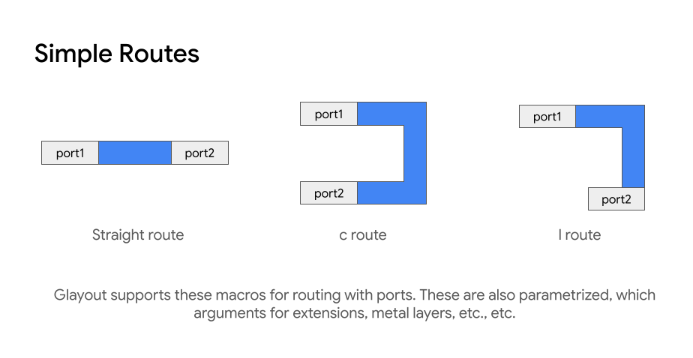

Now that the vias are placed, time to make metal routing.
There are three basic types of routing available:

- `straight_route` - the ports must be straight to each other, i.e, opposite direction and same x or y coordinate.
- `L_route` - has a 90&deg; bend, ports must be perpendicular to each other.
- `c_route` -  has two 90&deg; bends(c shaped), ports must have same direction.

Each routing function has multiple parameters. See [here](https://github.com/idea-fasoc/OpenFASOC/tree/main/openfasoc/generators/glayout/glayout/flow/routing)



### Port Routing Convention

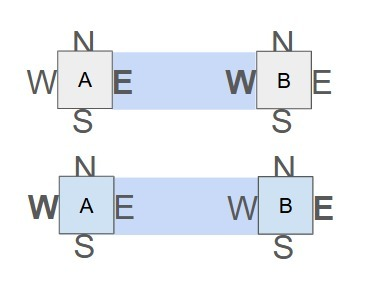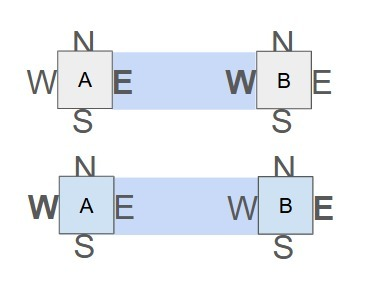
 
- The top diagram shows a connection from A's East port to B's West port — this routes metal through the narrow gap between the two components, which risks DRC violations due to spacing constraints.
- The bottom diagram shows the preferred approach: connecting A's West port to B's East port instead, routing the metal around the outside and keeping the space between components clear.

### Vertical Routes: Connecting Drain Nodes Through Vias

In [ ]:
# CM MIR drain → M1 diff pair drain
top_level << straight_route(pdk,
    drain_m3_via.ports["top_met_N"],
    drain_m1_via.ports["top_met_S"])

# CM REF drain → M2 diff pair drain
top_level << straight_route(pdk,
    drain_m4_via.ports["top_met_N"],
    drain_m2_via.ports["top_met_S"])

# Diff pair common source → tail drain
top_level << straight_route(pdk,
    source_m1_via.ports["top_met_N"],
    drain_m5_via.ports["top_met_S"])

display_component(top_level, scale=1, path="../../")

### Horizontal Routes: Connecting Sub-circuit Ports to Vias

In [ ]:
# Current mirror MIR drain → left via
top_level << straight_route(pdk,
    cm_ref.ports["M3_multiplier_0_drain_E"],
    drain_m3_via.ports["bottom_met_W"])

# Current mirror REF drain → right via
top_level << straight_route(pdk,
    cm_ref.ports["M4_multiplier_0_drain_W"],
    drain_m4_via.ports["bottom_met_E"])

# M1 drain → left via
top_level << straight_route(pdk,
    dp_ref.ports["M1_multiplier_0_drain_E"],
    drain_m1_via.ports["bottom_met_W"])

# M2 drain → right via
top_level << straight_route(pdk,
    dp_ref.ports["M2_multiplier_0_drain_W"],
    drain_m2_via.ports["bottom_met_E"])

# M2 source → tail drain via
top_level << straight_route(pdk,
    dp_ref.ports["M2_multiplier_0_source_E"],
    drain_m5_via.ports["bottom_met_W"])

# VDD: CM source to N+ tapring
top_level << straight_route(pdk,
    cm_ref.ports["M3_multiplier_0_source_E"],
    cm_ref.ports["TRING_W_top_met_W"])

# VSS: Tail source to P+ tapring
top_level << straight_route(pdk,
    tail_ref.ports["M6_multiplier_0_source_E"],
    tail_ref.ports["TRING_W_top_met_W"])

# Connect tail tapring to diff pair tapring
top_level << straight_route(pdk,
    dp_ref.ports["TRING_S_top_met_N"],
    tail_ref.ports["TRING_N_top_met_S"])

display_component(top_level, scale=1, path="../../")

## 9. Add Outermost Tapring

We add a final tapring that encloses the entire layout. This connects to the inner taprings of the sub-cells to form a continuous VSS guard ring.


In [ ]:
flat = top_level.flatten()
cx, cy = prec_center(flat)
actual_cx = -cx
actual_cy = -cy

tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(
    flat,
    padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]))

tring_ref = top_level << tap_ring
tring_ref.movex(destination=actual_cx)
tring_ref.movey(destination=actual_cy)

# Connect outer P+ tapring to inner P+ tapring
top_level << straight_route(pdk,
    tail_ref.ports["TRING_W_top_met_E"],
    tring_ref.ports["W_top_met_W"])

# Snap to grid and rename ports by orientation
component = component_snap_to_grid(rename_ports_by_orientation(top_level))
display_component(component, scale=2, path="../../")

## 10. I/O Port Vias & Pin Labeling

### Adding Via Stacks for I/O Signals

We place via stacks at each I/O port location, stepping up from metal 2 to metal 3. These vias serve as accessible landing pads for the top-level signals: VINP, VINN, VOUT, IN_CUR, VDD, and VSS.

In [ ]:
viam2m3 = via_stack(pdk, "met2", "met3", centered=True)

vinp_via   = top_level << viam2m3
vinn_via   = top_level << viam2m3
in_cur_via = top_level << viam2m3
vout_via   = top_level << viam2m3
vdd_via    = top_level << viam2m3
vss_via    = top_level << viam2m3

# Position each via at the corresponding port
vinn_via.move(dp_ref.ports["M1_multiplier_0_gate_W"].center)
vinp_via.move(dp_ref.ports["M2_multiplier_0_gate_E"].center)
in_cur_via.move(tail_ref.ports["M6_multiplier_0_drain_W"].center)
vout_via.move(dp_ref.ports["M1_multiplier_0_drain_W"].center)
vdd_via.move(cm_ref.ports["M3_multiplier_0_source_W"].center)
vss_via.move(tail_ref.ports["M5_multiplier_0_source_W"].center)

display_component(top_level, scale=2, path="../../")

### Exposing Ports to the Top Level

In [ ]:
# Add ports from sub-circuits
top_level.add_ports(cm_ref.get_ports_list(),   prefix="CM_")
top_level.add_ports(dp_ref.get_ports_list(),   prefix="DP_")
top_level.add_ports(tail_ref.get_ports_list(), prefix="TAIL_")

# Add ports from I/O vias
top_level.add_ports(vinp_via.get_ports_list(),   prefix="VINP_")
top_level.add_ports(vinn_via.get_ports_list(),   prefix="VINN_")
top_level.add_ports(in_cur_via.get_ports_list(), prefix="INCUR_")
top_level.add_ports(vout_via.get_ports_list(),   prefix="VOUT_")
top_level.add_ports(vdd_via.get_ports_list(),    prefix="VDD_")
top_level.add_ports(vss_via.get_ports_list(),    prefix="VSS_")

component = component_snap_to_grid(rename_ports_by_orientation(top_level))
display_component(component, scale=2, path="../../")

### Adding Pin Labels

We need to add I/O pins, power supply pins, and bias pins to the layout. These labels are required for LVS (Layout vs. Schematic) verification and parasitic extraction (PEX). 

In [ ]:
psize = (0.5, 0.5)
move_info = list()

# VSS
vsslabel = rectangle(layer=pdk.get_glayer("met2_pin"), size=psize, centered=True).copy()
vsslabel.add_label(text="VSS", layer=pdk.get_glayer("met2_label"))
move_info.append((vsslabel, component.ports["VSS_bottom_met_E"], None))

# VDD
vddlabel = rectangle(layer=pdk.get_glayer("met2_pin"), size=psize, centered=True).copy()
vddlabel.add_label(text="VDD", layer=pdk.get_glayer("met2_label"))
move_info.append((vddlabel, component.ports["VDD_bottom_met_E"], None))

# VINP
vinplabel = rectangle(layer=pdk.get_glayer("met2_pin"), size=psize, centered=True).copy()
vinplabel.add_label(text="VINP", layer=pdk.get_glayer("met2_label"))
move_info.append((vinplabel, component.ports["VINP_bottom_met_E"], None))

# VINN
vinnlabel = rectangle(layer=pdk.get_glayer("met2_pin"), size=psize, centered=True).copy()
vinnlabel.add_label(text="VINN", layer=pdk.get_glayer("met2_label"))
move_info.append((vinnlabel, component.ports["VINN_bottom_met_W"], None))

# VOUT
voutlabel = rectangle(layer=pdk.get_glayer("met2_pin"), size=psize, centered=True).copy()
voutlabel.add_label(text="VOUT", layer=pdk.get_glayer("met2_label"))
move_info.append((voutlabel, component.ports["VOUT_bottom_met_W"], None))

# IN_CUR
in_curlabel = rectangle(layer=pdk.get_glayer("met2_pin"), size=psize, centered=True).copy()
in_curlabel.add_label(text="IN_CUR", layer=pdk.get_glayer("met2_label"))
move_info.append((in_curlabel, component.ports["INCUR_bottom_met_W"], None))

for comp, prt, alignment in move_info:
    alignment = ('c', 'b') if alignment is None else alignment
    compref = align_comp_to_port(comp, prt, alignment=alignment)
    top_level.add(compref)

component = top_level.flatten()
display_component(top_level, scale=2, path="../../")
# top_level.show()

## 11. DRC Verification

The final step is to run a Design Rule Check (DRC) using Magic. The `drc_magic` function runs Magic's DRC engine on the component and returns a report of any violations.

A clean DRC result confirms that all spacing, enclosure, and width rules defined by the GF180 PDK are satisfied.

In [ ]:
component.name = "5T_OTA"
drc_result = gf180.drc_magic(component, component.name)